# Gradient Descent(경사 하강법)

*   머신 러닝의 목적은 손실(비용) 함수를 최소로 만드는 모델 파라미터(w0, w1, ...)들을 찾는 것.
*   회귀 문제에서는 비용 함수는 MSE(w)
    *   w에 대한 2차 함수의 최솟값의 위치를 찾는 문제.
*   경사 하강법: 함수의 최솟값의 위치를 찾는 알고리즘의 하나.
    *   함수의 임의의 위치 w 에서 시작.
    *   그 위치에서 접선의 기울기(gradient)를 계산.
    *   gradient의 절댓값이 줄어드는 방향으로 w 값을 약간 변경.
    *   위의 과정을 충분히 반복하면 함수가 최소가 되는 위치 w를 찾을 수 있음.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

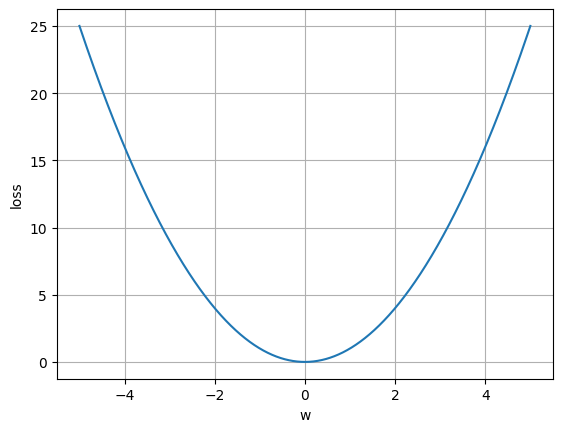

In [6]:
w = np.arange(-5, 5, 0.0001)
fn = w ** 2

plt.plot(w, fn)
plt.grid()
plt.xlabel("w")
plt.ylabel("loss")
plt.show()

In [10]:
# 임의의 w 위치를 선택
w_init = -4

# 선택한 위치(w_init)에서 함수의 접선의 기울기(gradient)를 계산
gradient = 2 * w_init

# 처음 위치에서 기울기의 반대 방향으로 약간 이동
w_next = w_init -  gradient * 0.1

w_next

-3.2

In [12]:
# 이동한 위치를 다시 시작.
w_init = w_next

# 다시 시작하는 위치에서 함수의 접선의 기울기를 계산
gradient = 2 * w_init

# 기울기의 반대 방향으로 약간 이동
w_next = w_init - gradient * 0.1

w_next

-2.048

In [22]:
def gradient_descent(learning_rate=0.1, max_iter=50, tolerance=0.0001):
    # f(w) = w^2 2차 함수를 시각화
    w = np.arange(-5, 5, 0.0001)
    fn = w ** 2
    plt.plot(w, fn, color="DarkGray")

    # 임의의 점에서 시작
    w_init = -4
    # 시작점의 위치를 점으로 표시
    plt.scatter(w_init, w_init ** 2, label="0")

    convergence = False
    for n in range(max_iter):
        # 시작점의 위치에서 gradient를 계산
        gradient = 2 * w_init  # f(w) = w^2 일 때, gradient = df/dw = 2 * w

        # gradient의 반대 방향으로 약간 이동
        w_next = w_init - gradient * learning_rate

        # 이동한 점의 위치를 점으로 표시
        plt.scatter(w_next, w_next ** 2, label=f"{n + 1}")

        # 반복을 계속할 지, 아니면 멈출 지를 결정.
        # 이동한 위치 w_next와 이동하기 전 위치 w_init 사이의 거리가
        # tolerance(기본값 0.0001)보다 작으면 반복을 멈춤.
        if np.abs(w_next - w_init) < tolerance:
            convergence = True
            break  # 반복문을 멈춤.

        # 다음 반복(iteration)을 시작하기 전에 시작 위치를 이동된 위치로 설정.
        w_init = w_next

    print("함수가 최소값인 w 위치 =", w_next)

    if convergence == False:
        print("ConvergenceWarning: 정확한 최솟값의 위치가 아닐 수 있습니다.")

    plt.legend()
    plt.grid()
    plt.xlabel("w")
    plt.ylabel("loss")
    plt.show()


함수가 최소값인 w 위치 = -0.0003402823669209386


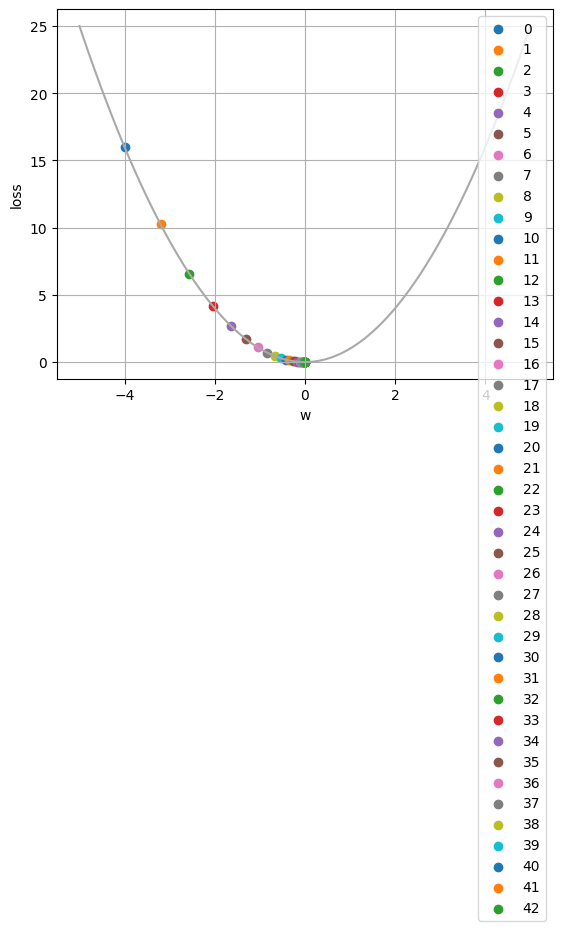

In [23]:
gradient_descent()

함수가 최소값인 w 위치 = -3.653754093327259e-05


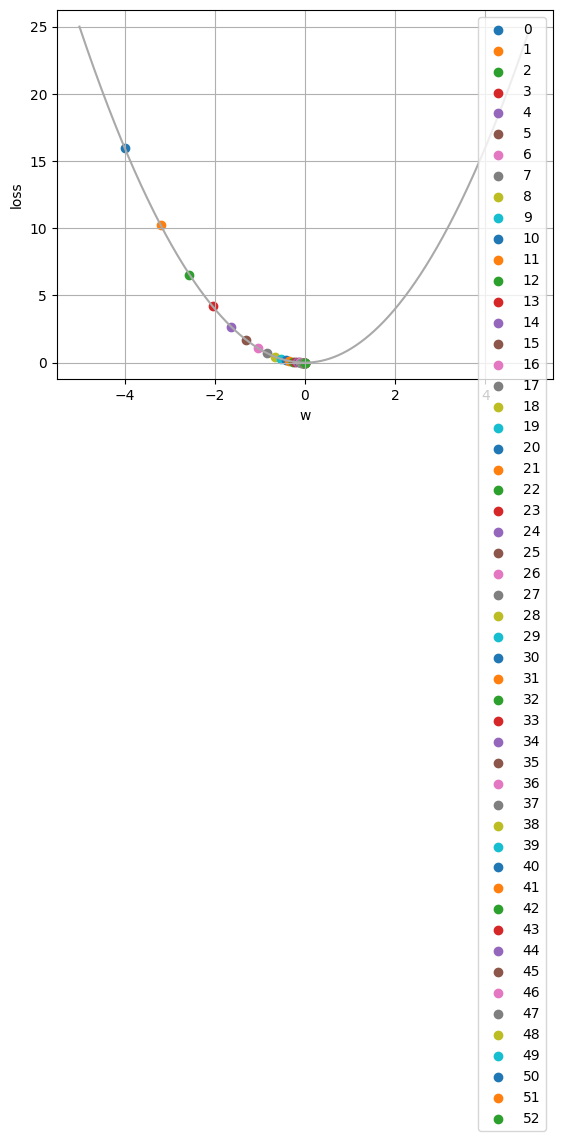

In [24]:
gradient_descent(max_iter=1_000, tolerance=0.00001)

함수가 최소값인 w 위치 = -0.4294967296000001


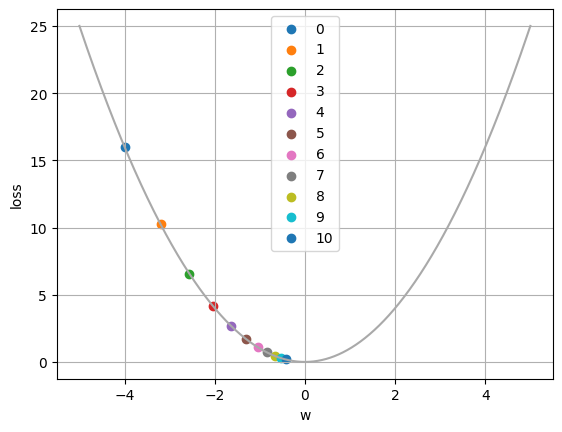

In [25]:
gradient_descent(max_iter=10)

함수가 최소값인 w 위치 = 3.158920892214423e-05


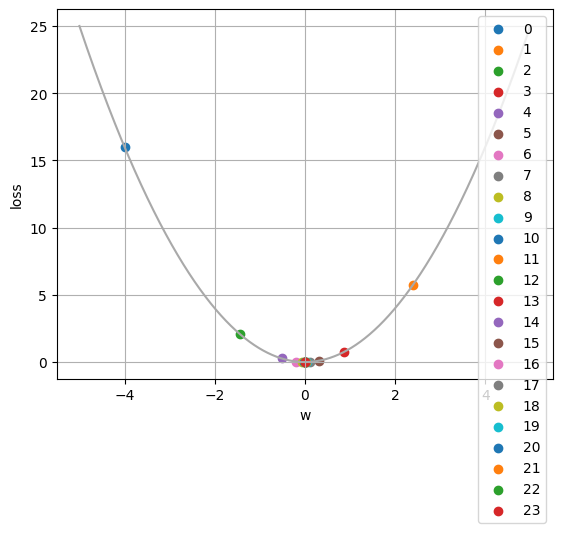

In [31]:
gradient_descent(learning_rate=0.8)

함수가 최소값인 w 위치 = -24.76694568960003


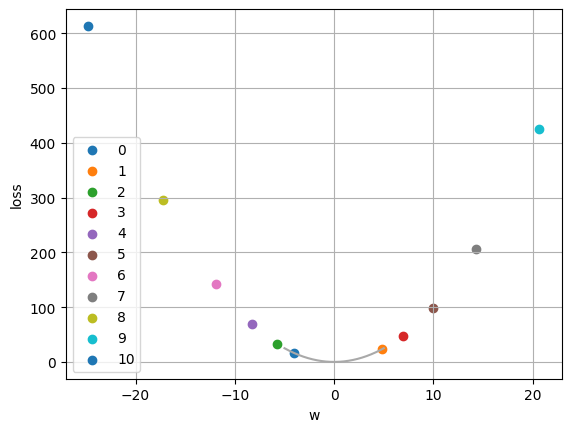

In [34]:
gradient_descent(learning_rate=1.1, max_iter=10)  # 발산(divergence)

** 학습률(learning rate) ** 하이퍼 파라미터

*   학습률이 작은 경우에는 최솟값을 향해서 천천히 움직임.
*   학습률이 큰 경우에는 최솟값을 향해서 빠르게 또는 불안정하게 움직임.
*   학습률이 너무 작으면 최대 반복 횟수(max_iter) 안에서 최솟값의 위치로 수렴(convergence)하지 못할 수도 있음.
    *   학습률을 더 크게 만듦.
    *   최대 반복 횟수(max_iter)를 늘려줌.
    *   수렴 반경(tolerance)를 더 크게 만듦.
*   학습률이 너무 크면 수렴하지 못하고 발산(divergence)하는 경우가 생기기도 함.
    *   학습률을 줄여야 함.
*   머신 러닝 알고리즘들 중에서는 처음에는 학습률을 크게 하고, 반복이 진행될 때마다 학습률을 점진적으로 줄여 나가는 방식으로 데이터를 학습하는 알고리즘도 있음.

# SGDRegressor

확률적 경사 하강법(Stochastic Gradient Descent) 알고리즘을 사용해서 손실 함수가 최소가 되는 모델 파라미터들을 찾고 수치를 예측하는 머신 러닝 모델.

In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor

In [36]:
file_path = "https://bit.ly/fish_csv_data"

In [37]:
fish = pd.read_csv(file_path)

In [39]:
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [40]:
perch = fish[fish.Species == "Perch"]

In [42]:
perch.head()

,Species,Weight,Length,Diagonal,Height,Width
72,Perch,5.9,8.4,8.8,2.1120,1.4080
73,Perch,32.0,13.7,14.7,3.5280,1.9992
74,Perch,40.0,15.0,16.0,3.8240,2.4320
75,Perch,51.5,16.2,17.2,4.5924,2.6316
76,Perch,70.0,17.4,18.5,4.5880,2.9415


In [60]:
x = perch[["Length"]].values  # 특성 배열
y = perch["Weight"].values  # 타겟 배열

In [61]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25,
                                                    random_state=42)

In [62]:
sgd = SGDRegressor()  # SGD 회귀 모델 생성

In [63]:
sgd.fit(X=x_train, y=y_train)

SGDRegressor()

In [64]:
sgd.predict(X=x_train)

array([3.36234595e+09, 4.07431533e+09, 3.09535743e+09, 2.70970735e+09,
       8.22747006e+09, 4.96427706e+09, 9.41408569e+09, 9.11743178e+09,
       1.03040474e+10, 4.07431533e+09, 3.48100751e+09, 4.07431533e+09,
       4.66762315e+09, 5.70591183e+09, 1.03040474e+10, 9.41408569e+09,
       4.66762315e+09, 3.77766142e+09, 5.70591183e+09, 9.41408569e+09,
       7.27817755e+09, 5.40925792e+09, 8.37579701e+09, 1.61208789e+09,
       4.28197307e+09, 1.99773797e+09, 8.52412397e+09, 7.93081615e+09,
       6.06189652e+09, 4.51929619e+09, 9.11743178e+09, 3.77766142e+09,
       4.37096924e+09, 4.07431533e+09, 1.06007013e+10, 4.22264229e+09,
       3.18435360e+09, 8.52412397e+09, 4.07431533e+09, 5.14226940e+09,
       1.00073935e+10, 7.78248919e+09])

In [65]:
sgd.score(X=x_train, y=y_train)  # 훈련 셋 R2 score(결정계수)

-344736529165761.2

In [66]:
sgd.score(X=x_test, y=y_test)  # 테스트 셋 결정계수

-359874678336989.25

훈련 셋의 샘플 개수가 너무 작아서 1,000번(max_iter) 반복하는 것으로는 최적의 값으로 수렴하지 못함.

해결 방법:
*   최대반복 횟수(max_iter)를 늘려줌.
*   규제의 크기(alpha)를 줄임.
*   학습률(learning_rate, eta0, power_t)을 키움.

*   SGDRegressor 사용
    *   max_iter = 1_000_000_000
    *   learning_rate = ["constant", 'invscaling', 'adaptive']
    *   eta0 = [0.01, 0.1, 0.3, 0.5, 1.0] : 초기 학습률.

In [68]:
max_iter = 1_000_000_000
learning_rate = ["constant", 'invscaling', 'adaptive']
eta0 = [0.01, 0.1, 0.3, 0.5, 1.0]

tr_sc = []
te_sc = []

for lr in learning_rate:
    for e in eta0:
        sgd = SGDRegressor(max_iter=max_iter, learning_rate=lr, eta0=e)
        sgd.fit(X=x_train, y=y_train)
        train_score = sgd.score(X=x_train, y=y_train)
        tr_sc.append(train_score)

        test_score = sgd.score(X=x_test, y=y_test)
        te_sc.append(test_score)
    print(f"scores for train set where learning_rate: {lr} = {tr_sc}")
    print(f"scores for test set where learning_rate: {lr} = {te_sc}")

scores for train set where learning_rate: constant = [-2.366561107810843e+18, -3.164690345995908e+22, -2.4315926412173495e+23, -2.481767945391074e+24, -8.892307427275863e+24]
scores for test set where learning_rate: constant = [-2.564282417589577e+18, -3.408819455870447e+22, -2.6216720532331126e+23, -2.6746286357748014e+24, -9.585968794881774e+24]
scores for train set where learning_rate: invscaling = [-2.366561107810843e+18, -3.164690345995908e+22, -2.4315926412173495e+23, -2.481767945391074e+24, -8.892307427275863e+24, -732054599042.4171, -2.614713432292555e+18, -2.479228644743157e+21, -5.8522766955085465e+22, -5.12289357897607e+22]
scores for test set where learning_rate: invscaling = [-2.564282417589577e+18, -3.408819455870447e+22, -2.6216720532331126e+23, -2.6746286357748014e+24, -9.585968794881774e+24, -880791283118.3802, -2.8132554260479e+18, -2.6850739516893556e+21, -6.316473104855741e+22, -5.544306187233884e+22]


KeyboardInterrupt: 

In [69]:
# 강사님 답안
max_iterations = 1_000_000_000  # 최대 반복 횟수
learning_rates = ['constant', 'invscaling', 'adaptive']  # 학습률 변경 방법
eta0s = [0.01, 0.1, 0.3, 0.5, 1.0]  # 초기 학습률

for lr in learning_rates:
    for eta in eta0s:
        # SGD 회귀 모델을 생성
        sgd = SGDRegressor(max_iter=max_iterations, learning_rate=lr, eta0=eta,
                           random_state=42)

        # 모델 훈련
        sgd.fit(X=x_train, y=y_train)

        # 훈련 셋 결정계수
        train_score = sgd.score(X=x_train, y=y_train)

        # 테스트 셋 결정계수
        test_score = sgd.score(X=x_test, y=y_test)
        print(f"learning rate={lr}, ets0={eta}, train r2={train_score:.3e}, test r2={test_score:.3e}")

learning rate=constant, ets0=0.01, train r2=-4.248e+20, test r2=-4.579e+20
learning rate=constant, ets0=0.1, train r2=-6.131e+22, test r2=-6.601e+22
learning rate=constant, ets0=0.3, train r2=-5.317e+23, test r2=-5.723e+23
learning rate=constant, ets0=0.5, train r2=-3.758e+23, test r2=-4.056e+23
learning rate=constant, ets0=1.0, train r2=-5.958e+24, test r2=-6.417e+24
learning rate=invscaling, ets0=0.01, train r2=-1.479e+13, test r2=-1.650e+13
learning rate=invscaling, ets0=0.1, train r2=-8.941e+20, test r2=-9.604e+20
learning rate=invscaling, ets0=0.3, train r2=-1.070e+21, test r2=-1.143e+21
learning rate=invscaling, ets0=0.5, train r2=-5.037e+21, test r2=-5.410e+21
learning rate=invscaling, ets0=1.0, train r2=-1.849e+22, test r2=-1.988e+22
learning rate=adaptive, ets0=0.01, train r2=9.146e-01, test r2=6.976e-01
learning rate=adaptive, ets0=0.1, train r2=9.200e-01, test r2=8.681e-01
learning rate=adaptive, ets0=0.3, train r2=-4.953e+18, test r2=-8.170e+18
learning rate=adaptive, ets0=